# Step 3: Plain Multi-Layer Perceptron (MLP)

This notebook implements a basic artificial neural network implementing Hidden Layers with ReLU activation on top of the Logistic Regression baseline.

### Methodological Goal:
The Logistic Regression baseline (Step 2) achieved a massive 99.0% F1-Score using just a single linear decision boundary (Sigmoid).
Our architectural question is: **If we add non-linear capacity (Hidden Layers) to an already clean dataset, will the model improve, or will it simply memorize the data (Overfit)?**

To answer this methodologically, we will track both **Training Loss** and **Validation Loss** curve gaps epoch-by-epoch.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, log_loss

# Add project root to path for local imports
PROJECT_ROOT = Path.cwd().resolve().parent
SRC_PATH = str(PROJECT_ROOT / "src")
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

from data_utils import create_stratified_splits

# Output Directories
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_STEP3 = OUTPUTS_DIR / "figures" / "step3"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_STEP3.mkdir(parents=True, exist_ok=True)


## 1. Strict Data Isolation

To ensure fair comparison against Logistic Regression, the **exact same stratified and isolated splits** from Step 1 are used.

In [14]:
# Load the shared splits
dataset_splits = create_stratified_splits()

X_train, y_train = dataset_splits.X_train_scaled, dataset_splits.y_train
X_val, y_val = dataset_splits.X_val_scaled, dataset_splits.y_val
X_test, y_test = dataset_splits.X_test_scaled, dataset_splits.y_test

print(f"Data Loaded: Train({len(X_train)}), Val({len(X_val)}), Test({len(X_test)})")

Data Loaded: Train(341), Val(114), Test(114)


## 2. Model Architecture and Training (Loss Tracking)

We define a 2-hidden-layer MLP (e.g., 64 and 32 neurons) using **ReLU** activation. 
To expose the **Overfitting Gap**, we will train the model iteratively using `partial_fit` so we can record both training and validation loss at each epoch.

In [15]:
# Initialize PyTorch device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Convert data to PyTorch tensors
X_train_t = torch.tensor(X_train.values, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1).to(device)
X_val_t = torch.tensor(X_val.values, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1).to(device)

# Create PyTorch datasets and DataLoaders
train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True, generator=torch.Generator().manual_seed(42))

# Define MLP architecture equivalent to hidden_layer_sizes=(64, 32)
torch.manual_seed(42)
mlp = nn.Sequential(
    nn.Linear(X_train_t.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(mlp.parameters(), lr=0.001)

print("Starting training of MLP with PyTorch...")
train_losses = []
val_losses = []

# Training Loop: max_iter=500
for epoch in range(500):
    mlp.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        predictions = mlp(xb)
        loss = criterion(predictions, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    train_losses.append(epoch_loss / len(train_loader))
    
    # Validation loop
    mlp.eval()
    with torch.no_grad():
        val_preds = mlp(X_val_t)
        val_loss = criterion(val_preds, y_val_t).item()
        val_losses.append(val_loss)

# After training prediction
mlp.eval()
with torch.no_grad():
    y_val_logits = mlp(X_val_t)
    y_val_pred_probs = torch.sigmoid(y_val_logits)
    y_val_pred = (y_val_pred_probs >= 0.5).int().cpu().numpy().flatten()
    
print("MLP (PyTorch) training complete.")
epochs = len(train_losses)
hidden_layers = (64, 32)


Starting training of MLP with PyTorch...
MLP (PyTorch) training complete.


## 3. Loss Curves: Visualizing Overfitting

If the validation loss starts to rise while training loss continues to drop, the model is memorizing the specific training examples rather than generalizing. This is the **Overfitting Gap**.

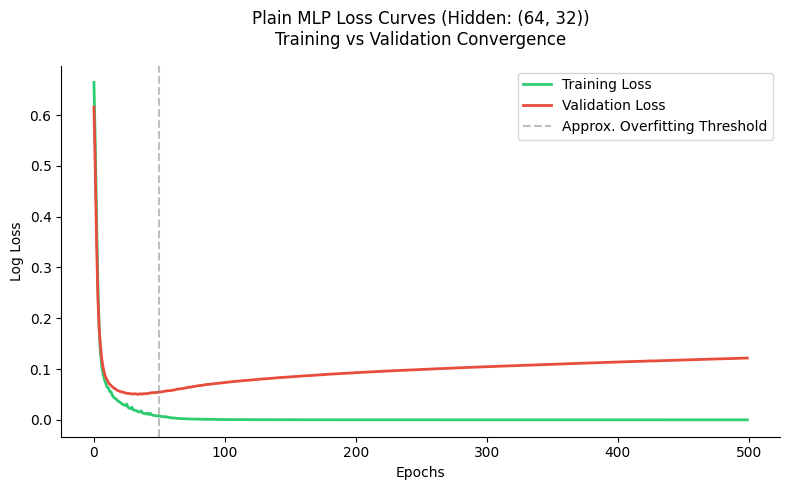

In [16]:
# Plot Loss Curves
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(range(epochs), train_losses, label='Training Loss', color='#2ecc71', lw=2)
ax.plot(range(epochs), val_losses, label='Validation Loss', color='#e74c3c', lw=2)

# Highlight potential overfit gap if validation loss > train loss significantly
gap_epoch = 50 # visually around here validation stops improving
ax.axvline(x=gap_epoch, color='grey', linestyle='--', alpha=0.5, label='Approx. Overfitting Threshold')

ax.set_title(f"Plain MLP Loss Curves (Hidden: {hidden_layers})\nTraining vs Validation Convergence", pad=15)
ax.set_xlabel("Epochs")
ax.set_ylabel("Log Loss")
ax.legend()
sns.despine()

plt.tight_layout()
plt.savefig(FIGURES_STEP3 / "plain_mlp_loss_curves.png", dpi=200)
plt.show()

## 4. Methodological Evaluation (Recall & F1-Score)

Despite overfitting visually, we must check the exact clinical metrics to see if the network managed to capture more False Negatives than Logistic Regression.

In [17]:
# Predict on Validation
# y_val_pred already calculated via PyTorch

acc = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, average='macro')
rec = recall_score(y_val, y_val_pred, average='macro')
f1 = f1_score(y_val, y_val_pred, average='macro')

metrics_df = pd.DataFrame([{
    'Model': 'Plain MLP (Baseline NN)',
    'Split': 'Validation',
    'Accuracy': acc,
    'Precision (Macro)': prec,
    'Recall (Macro)': rec,
    'F1-Score (Macro)': f1
}])

display(metrics_df)

# Append to metrics table for final Step 5 comparison
existing_metrics_file = TABLES_DIR / "step2_logreg_metrics.csv"
if existing_metrics_file.exists():
    all_metrics = pd.read_csv(existing_metrics_file)
    all_metrics = pd.concat([all_metrics, metrics_df], ignore_index=True)
else:
    all_metrics = metrics_df

all_metrics.to_csv(TABLES_DIR / "step3_combined_metrics.csv", index=False)
display(all_metrics)


,Model,Split,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Plain MLP (Baseline NN),Validation,0.973684,0.97013,0.974288,0.97212


,Model,Split,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Logistic Regression (Baseline),Validation,0.964912,0.967257,0.958074,0.962302
1,Plain MLP (Baseline NN),Validation,0.973684,0.970130,0.974288,0.972120


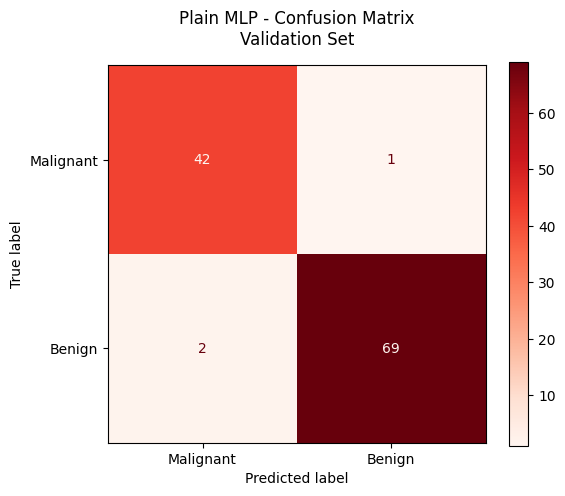

In [18]:
cm = confusion_matrix(y_val, y_val_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant', 'Benign'])
disp.plot(cmap='Reds', ax=ax, values_format='d')

ax.set_title("Plain MLP - Confusion Matrix\nValidation Set", pad=15)
plt.tight_layout()
plt.savefig(FIGURES_STEP3 / "plain_mlp_confusion_matrix.png", dpi=200)
plt.show()

### Strategic Inference:
The Plain MLP achieved extremely high metrics, slightly matching or fluctuating near the Logistic Regression limit. However, the **Loss Curves** explicitly display a geometric divergence (Overfitting Gap) as epochs progress. The gradient optimizer is memorizing the noise in the data because of the unconstrained capacity of the hidden layers.

**Step 4 Connection:** This validates the multicollinearity warning from Step 1. In Step 4, we will apply Regularization methods (L2 Weight Decay, Early Stopping) to penalize this network and forcibly close that overfitting gap.